In [1]:
import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output
import math

In [2]:
def check_pd(matrix: torch.Tensor):
    """
    Checks if a given 2D PyTorch tensor is positive definite (PD) or 
    positive semi-definite (PSD) or neither.
    
    Args:
        matrix (torch.Tensor): A 2D square PyTorch tensor.

    Returns:
        str: "Positive Definite", "Positive Semi-Definite", or "Neither"
    """
    if not (matrix.dim() == 2 and matrix.shape[0] == matrix.shape[1]):
        raise ValueError("Input must be a square matrix")

    try:
        # Attempt Cholesky decomposition for positive definiteness
        torch.linalg.cholesky(matrix)
        return "Positive Definite"
    except RuntimeError:
        # Compute eigenvalues for semi-definiteness check
        eigenvalues = torch.linalg.eigvalsh(matrix)
        if torch.all(eigenvalues >= 0):
            return "Positive Semi-Definite"
        else:
            return "Neither"

In [ ]:
def MatViz3d(matrix: torch.Tensor):
    """
    Plots a 3D surface representation of a 2D PyTorch tensor.
    
    Args:
        matrix (torch.Tensor): A 2D tensor representing the surface.
    
    Raises:
        ValueError: If the input is not a 2D tensor.
    """
    if not (matrix.dim() == 2):
        raise ValueError("Input must be a 2D tensor")

    # Convert to NumPy
    matrix_np = matrix.cpu().detach().numpy()
    
    # Create meshgrid for X, Y indices
    x = np.arange(matrix_np.shape[1])
    y = np.arange(matrix_np.shape[0])
    X, Y = np.meshgrid(x, y)

    # Create figure and 3D axis
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot surface
    surf = ax.plot_surface(X, Y, matrix_np, cmap='viridis', edgecolor='k')

    # Add colorbar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.6)
    cbar.set_label('Element Value')

    # Labels
    ax.set_xlabel('Column Index')
    ax.set_ylabel('Row Index')
    ax.set_zlabel('Value')
    ax.set_title(f'3D Surface Plot | Max={np.max(matrix_np)}, Min={np.min(matrix_np)}')

    plt.show()



In [4]:
# Allowed system names -
# "Unforced Duffing"
# "van der Pol"
# "Simple Pendulum"
# "Lorenz"
# "Lotka Volterra"
system_name = 'Unforced Duffing'
data = torch.load(f"Data/DataAuto_{system_name}_right.pt", weights_only=True)

SimData = data["trajectories"] # Shape: (num_trajectories, state_dim, num_steps)
ts = data["sample_time"]
num_trajectories = data["num_trajectories"]
N = data["num_steps"]
nTrain = math.floor(num_trajectories * 0.5)
nTest = math.floor(num_trajectories * 0.2)

SimData = SimData.float()
n = SimData.shape[1]

p = 20  # number of lifted states
l = 31  # decision horizon for each lifted state
r = 10   # resolution along all dimensions

Xall = torch.cat([SimData[j, :, :] for j in range(nTrain)], dim=1)      # Concatenated total matrix
X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)       # Concatenated Data matrix
Xplus = torch.cat([SimData[j, :, 1:] for j in range(nTrain)], dim=1)    # Time-shifted Data matrix
ICsetTrain = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain)], dim=1)    # Random IC set for training
ICsetTest = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain, nTrain + nTest)], dim=1)  # Random IC set for testing

Kmm is Positive Definite
invKmm is Positive Definite
v0 is Positive Semi-Definite


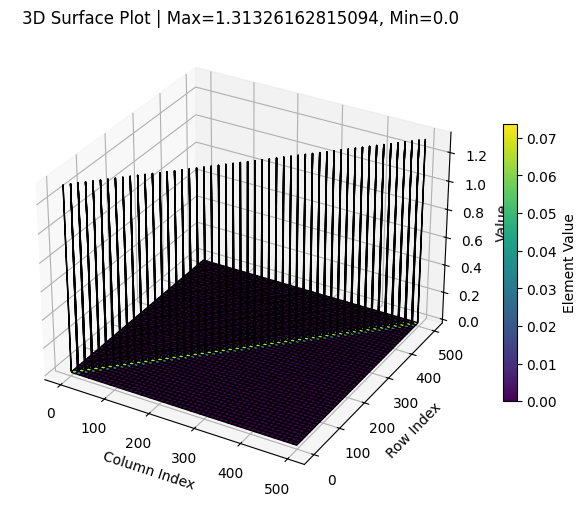

In [ ]:
torch.manual_seed(1234)

ns = 1000
x_start, x_end = 0., 2.
Xtrain0 = torch.linspace(x_start, x_end, ns).view(1,ns)
Z0 = torch.sin(Xtrain0[0,:]) * Xtrain0[0,:] ** 2

hp1, hp2 = [torch.tensor(1.)], [torch.tensor(0.001)]
gp0 = gpk.GPObservable(d=1,ns=ns,kernel_types=['Gaussian'], hp1_list=hp1, hp2_list=hp2, noise=1e-6, m=500)
gp0.trainGP(Xtrain=Xtrain0, ytrain=Z0)

xq1 = 10*torch.rand(1,10).view(1,10)
m0, v0 = gp0.predictGP(xq1)

print(f'Kmm is {check_pd(gp0.Kmm)}')
print(f'invKmm is {check_pd(gp0.invKmm)}')

print(f'v0 is {check_pd(v0)}')

MatViz3d(gp0.Kmm)



In [6]:
torch.sort(torch.linalg.eigvalsh(gp0.Kmm).real)

torch.return_types.sort(
values=tensor([-5.6734e-05, -5.5745e-05, -4.3163e-05,  ...,  2.4766e+02,
         4.6448e+02,  6.8230e+02], device='cuda:0', grad_fn=<SortBackward0>),
indices=tensor([   0,    1,    2,  ..., 1547, 1548, 1549], device='cuda:0'))

In [ ]:
torch.manual_seed(1234)
indices = torch.linspace(0, N-1, steps=l).long()
Xtrain = torch.cat([SimData[j, :, indices] for j in range(nTrain)], dim=1)
Z = torch.rand(ns, 1, requires_grad=True)

gp1 = gpk.GPObservable(d=2,ns=ns,kernel_types=['Gaussian'],noise=1e-6, m=200)

gp1.trainGP(Xtrain=Xtrain, ytrain=Z)

m1, v1 = gp1.predictGP(xq1)


In [15]:
check_pd(v0)

'Neither'